Projet segmentez des clients d'un site e-commerce

notebook simulation pour le contrat de maintenance

Created by: Thomas Durand-Texte, 2023

**Table of contents**<a id='toc0_'></a>    
- 1. [Import des packages et données](#toc1_)    
  - 1.1. [import des packages](#toc1_1_)    
  - 1.2. [Paramètres graphiques et fonctions utiles](#toc1_2_)    
  - 1.3. [Chargement des données](#toc1_3_)    
- 2. [Fonctions utiles](#toc2_)    
- 3. [Contrat de maintenance](#toc3_)    
  - 3.1. [k = 5](#toc3_1_)    
  - 3.2. [k = 4](#toc3_2_)    
  - 3.3. [Remarques](#toc3_3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Import des packages et données](#toc0_)
## 1.1. <a id='toc1_1_'></a>[import des packages](#toc0_)

In [1]:
import os

import pandas as pd
import numpy as np
# import dask as dd
pd.set_option("display.max_columns", 200)
import datetime as dt
import scipy.stats as st

from statsmodels.multivariate.manova import MANOVA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda

import time

import pickle

from sklearn import model_selection, metrics, preprocessing
from sklearn import cluster

import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

import plotly.express as px

cm = 1./2.54
path_print = 'Figures/simulations/'

## 1.2. <a id='toc1_2_'></a>[Paramètres graphiques et fonctions utiles](#toc0_)

In [2]:
import subprocess

white_font = True
def set_theme(white_font=True):
    """Réglages graphiques

    Args:
        white_font (bool, optional): set if font a set to white (True) or black (False). Defaults to True.
    """
    if white_font: wht, grey, blck = '0.84' , '0.5', 'k'
    else: wht, grey, blck = 'k', '0.5', '0.84'
    rc = { 'figure.facecolor':(0.118,)*3,
            'axes.labelcolor':wht,
            'axes.edgecolor':wht,
            'axes.facecolor':(0,0,0,0),
            'text.color':'white',
            'text.usetex':False,
            'text.latex.preamble':r'\usepackage[cm]{sfmath} \usepackage{amsmath}' ,
            'font.family': 'sans-serif' ,
            'font.sans-serif': 'DejaVu Sans' ,
            'xtick.color':wht,
            'ytick.color':wht,
            "axes.grid" : True,
            "grid.color": (0.7,)*3,
            "grid.linewidth": 0.4,
            "grid.linestyle": (10,5),
            'legend.edgecolor':'0.2',
            'legend.facecolor':(0.2,0.2,0.2,0.6),
            # 'legend.framealpha':'0.6',
            'pdf.fonttype':42,
            'savefig.format':'pdf',
            'savefig.transparent':True,
            'figure.dpi':150, # for better agreemet figsize vs real size
        }

    sns.set_theme('notebook' , rc=rc)
    return


def make_folder(path_folder:str):
    """Create a folder given the path. Test is performed first to check if folder already exists or not.

    Args:
        path_folder (str): path to the folder
    """
    path_folder = path_folder.__str__()
    try:
        if os.path.isdir(path_folder) : return
        os.makedirs(path_folder)
    except OSError:
        pass
    return


def concat_folders(*args, **kwargs)->str:
    """Concatenate strings to form a path to a folder

    exemple concat_filders('/abc', 'ABC') -> '/abc/ABC/'

    Returns:
        str: concatenated string corresponding to a path to a folder
    """
    sPath = ''
    for arg in args:
        if arg == '..': sPath = sPath[:sPath[:-1].rfind(os.sep)+1]
        else: sPath += arg
        if sPath[-1] != os.sep: sPath += os.sep
    return sPath


class Path(object):
    """ Path(s_in='', s_lim=None)
        create a path to the string s_in (default is current path)
        and stops after s_lim """
    n_Path = 0
    def __init__(self, s_in='', s_lim=None):
        """Initialisation of class Path

        Args:
            s_in (str, optional): string corresponding to a folder path. Defaults to '' (current working directory).
            s_lim (_type_, optional): chain to limit the path. Defaults to None. Example s_in = '/folder_1/folder_2/folder_3', s_lim = '2', leads to '/folder_1/folder_2/'
        """
        if s_in == '': s_in = os.getcwd()
        if not s_lim is None:
            if s_lim in s_in:
                s_in = s_in[ :s_in.index(s_lim) + len(s_lim) ]
        self.sPath = concat_folders(s_in)
        self.N = Path.n_Path
        Path.n_Path += 1
        return

    def __add__(self, other):
        """ Path + str : return str """
        if isinstance(other, str): return self.sPath + other

    def __truediv__(self, other):
        """ Path / str : return path concatenated"""
        if isinstance(other, str): return Path(concat_folders(self.sPath, other))

    def __invert__(self):
        """ ~Path : return str of the path """
        return self.sPath

    def __str__(self):
        """ __str__ return str of the path """
        return self.sPath
    # __str__ #

    def makedir(self):
        """ Create a folder from current path if it does not exists """
        return make_folder(self)


def gs_opt(filename:str):
    """otpimisation of a pdf file with gosthscript

    Args:
        filename (str): string corresponding to the pdf file to optimise
    """
    filenameTmp = filename.replace('.pdf', '') + '_tmp.pdf'
    gs = ['gs',
            '-sDEVICE=pdfwrite',
            '-dEmbedAllFonts=true',
            '-dSubsetFonts=true',             # Create font subsets (default)
            '-dPDFSETTINGS=/prepress',        # Image resolution
            '-dDetectDuplicateImages=true',   # Embeds images used multiple times only once
            '-dCompressFonts=true',           # Compress fonts in the output (default)
            '-dNOPAUSE',                      # No pause after each image
            '-dQUIET',                        # Suppress output
            '-dBATCH',                        # Automatically exit
            '-sOutputFile='+filenameTmp,      # Save to temporary output
            filename]                         # Input file

    subprocess.run(gs)                                      # Create temporary file
    subprocess.run('rm -f ' + filename, shell=True)            # Delete input file
    subprocess.run('mv -f ' + filenameTmp + " " + filename, shell=True) # Rename temporary to input file


def savefig(fig, savename:str, **kwargs):
    """Saves a figure with kwargs (fig.savefig(savename, **kwargs)).
       A check is done first to determine if a folder has to be created according to savename.
       Finally, if the file is saved as .pdf, gosthscript optimisation is performed.

    Args:
        fig : matplotlib figure
        savename (str): string of the name of the output pdf file
    """


    if os.sep in savename: make_folder(savename[:savename.rindex(os.sep)])
    fig.savefig(savename, **kwargs)
    savename += '.pdf'
    if os.path.isfile(savename): gs_opt(savename)
    return


def image_size_from_shape(shape: tuple, width: float = None, height: float = None, ymargin=0.):
    """Compute tuple (width, height) from shape tuple of an image an width or height

    Args:
        shape (tuple): shape of the image (n_rows, n_cols)
        width (float, optional): desired width. Defaults to None.
        height (float, optional): desired height. Defaults to None.
        ymargin (_type_, optional): margin added to the output height. Defaults to 0..

    Returns:
        tuple: (width, height)
    """
    if not width is None:
        return width, width*shape[0]/shape[1] + ymargin
    if not heihgt is None:
        return height*shape[1]/shape[0]+xmargin, height
    else:
        print('\n!!! image_size_from_shape: nor width nor heigth was provided !!!\n')
        return shape


set_theme()
del set_theme

## 1.3. <a id='toc1_3_'></a>[Chargement des données](#toc0_)

Affichage de l'arborescence

In [3]:
def print_listdir(path=None, level=0, exclude=[]):
    """Affiche l'arborescence des dossiers et fichiers

    Args:
        path (_type_, optional): chemin du dossier à explorer. Defaults to None.
        level (int, optional): niveau d'indentation. Defaults to 0.
        exclude (list, optional): dossiers = exclure. Defaults to [].
    """
    suffix = ''
    if level > 0:
        suffix = ' |-'* level
    vals = os.listdir(path)
    vals.sort()
    if path is None:
        path = ''
    for val in vals:
        if val in exclude: continue
        print(suffix, val)
        if os.path.isdir(path + val):
            print_listdir(path + val + '/', level+1)

print_listdir(exclude=['.venv', '.venv2', 'Figures', 'diaporama', 'ressources', 'devel'])

 data
 |- cleaned
 |- |- iteration_tsne_RFM.pickle
 |- |- iteration_tsne_RFM_delay.pickle
 |- |- iteration_tsne_RFM_review_score.pickle
 |- |- iteration_tsne_RFM_type_payment.pickle
 |- data_diagram.png
 |- data_diagram_resized.png
 |- source
 |- |- olist_customers_dataset.csv
 |- |- olist_customers_dataset.csv.zip
 |- |- olist_geolocation_dataset.csv
 |- |- olist_geolocation_dataset.csv.zip
 |- |- olist_order_items_dataset.csv
 |- |- olist_order_items_dataset.csv.zip
 |- |- olist_order_payments_dataset.csv
 |- |- olist_order_payments_dataset.csv.zip
 |- |- olist_order_reviews_dataset.csv
 |- |- olist_order_reviews_dataset.csv.zip
 |- |- olist_orders_dataset.csv
 |- |- olist_orders_dataset.csv.zip
 |- |- olist_products_dataset.csv
 |- |- olist_products_dataset.csv.zip
 |- |- olist_sellers_dataset.csv
 |- |- product_category_name_translation.csv
 exploration.ipynb
 install_packages_venv.sh
 install_packages_venv2.sh
 notebook.ipynb
 notebook_essais.ipynb
 notebook_simulation.ipynb
 note

Chargement des données

In [43]:
path = 'data/source/'

filenames = ['customers', 'geolocation', 'orders', 'order_items', 'order_payments', 'order_reviews', 'products', 'sellers']
dfs = {filename: pd.read_csv(path + f'olist_{filename}_dataset' + '.csv') for filename in filenames}
filename = 'product_category_name_translation'
dfs[filename] = pd.read_csv(path + filename + '.csv')

path_save = 'data/cleaned/'

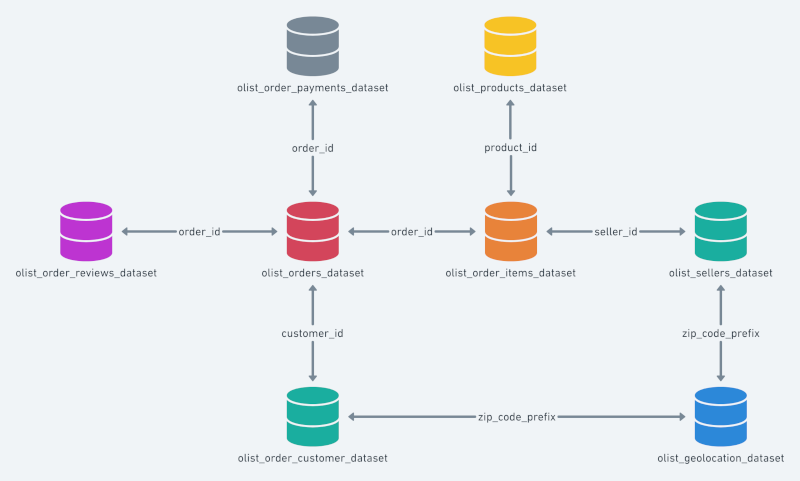

In [44]:
df_merged = dfs['orders'].merge(dfs['customers'], how='left', on='customer_id')
df_merged = df_merged.merge( dfs['order_payments'], how='left', on='order_id')
df_merged = df_merged.merge( dfs['order_reviews'], how='left', on='order_id')

df_merged.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
93134,43ad25e09be659b55ed165e2dd94f360,46aa4fd9f28218dc3f9f057b90b01255,delivered,2017-04-26 12:18:53,2017-04-27 13:23:02,2017-04-28 17:47:18,2017-05-09 08:29:08,2017-05-29 00:00:00,7b662d846265cb0ed144db95fe0c74dc,56780,tabira,PE,1.0,credit_card,2.0,159.83,94b7a978209d8540037fcad648624562,5.0,NaN,NaN,2017-05-10 00:00:00,2017-05-13 22:22:37
25182,372ffaa162f256187848bfa1d66b6808,9132e57f9a51cf382ef609835a24aa2d,delivered,2018-01-22 20:24:43,2018-01-22 20:37:29,2018-01-24 19:08:05,2018-01-30 22:38:23,2018-02-14 00:00:00,95ccc510f68e05d7ecceb58a4f37558a,19780,quata,SP,1.0,credit_card,4.0,45.48,2a3b61b923295d1c8c3a2bc817ddf8c7,5.0,NaN,NaN,2018-01-31 00:00:00,2018-02-01 09:59:51
49959,852d2f4d37773bcbc21c8e09a05a4ea5,eabebad39a88bb6f5b52376faec28612,delivered,2018-03-07 15:57:14,2018-03-07 16:15:30,2018-03-12 23:02:49,2018-03-15 00:46:30,2018-03-19 00:00:00,295c05e81917928d76245e842748184d,5704,sao paulo,SP,1.0,credit_card,3.0,36.39,360df94a293698ff75fcd3779bcca3bd,3.0,NaN,Produto chegou no prazo o problema que veio na...,2018-03-16 00:00:00,2018-03-16 11:12:20
21249,d355c1d4bd77e3cd62085deff064434a,8e80b162ca67be702f8eea30f9759c94,delivered,2017-10-25 21:55:29,2017-10-27 03:10:09,2017-10-27 21:03:33,2017-11-13 19:08:41,2017-11-21 00:00:00,465b5aba99bc6d617f04baeb951e1083,88701,tubarao,SC,1.0,boleto,1.0,94.31,68da8c0b251599be554dea4e46b98197,1.0,NaN,veio um lustre totalmente diferente do solicit...,2017-11-14 00:00:00,2017-11-14 11:51:33
29871,b0cfe2eb432bba9a53dce35cd5793946,b7908345fe15cf0013c5f73d12225cab,delivered,2017-09-27 19:45:47,2017-09-29 02:28:45,2017-09-29 20:02:07,2017-10-15 14:21:20,2017-10-26 00:00:00,deec1195aa524d200f3c9da638571d86,91760,porto alegre,RS,1.0,boleto,1.0,86.73,83769c402bf157486ce10d8b62fd0e29,5.0,NaN,Chegou perfeito,2017-10-16 00:00:00,2017-10-16 16:54:00


In [45]:
timestamp_cols = ['order_purchase_timestamp', 'order_approved_at',
                  'order_delivered_carrier_date', 'order_delivered_customer_date',
                  'order_estimated_delivery_date'
                 ]
for col in timestamp_cols:
    df_merged[col] = pd.to_datetime(df_merged[col])

In [46]:
loc = df_merged['order_status'] == 'delivered'

key = 'delivery_time'
df_merged[key] = np.nan
df_merged.loc[loc, key] = df_merged.loc[loc, 'order_delivered_customer_date'] - df_merged.loc[loc, 'order_purchase_timestamp']

key = 'estimated_delivery_time'
df_merged[key] = np.nan
df_merged.loc[loc, key] = df_merged.loc[loc, 'order_estimated_delivery_date'] - df_merged.loc[loc, 'order_purchase_timestamp']

# DELIVRY DELAY, EXPRESSED IN HOURS
key = 'delivery_delay'
df_merged[key] = np.nan
delay = df_merged.loc[loc, 'delivery_time'] - df_merged.loc[loc, 'estimated_delivery_time']
df_merged.loc[loc, key] = 24*delay.dt.days + delay.dt.seconds/3600

df_merged.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_time,estimated_delivery_time,delivery_delay
85149,6b0eaae462243e328c81413a0b1968ed,d76e9fe365aae1bb4307f9676894d9c3,delivered,2018-02-19 10:53:23,2018-02-20 14:35:27,2018-02-21 20:37:04,2018-02-24 14:48:54,2018-03-05,1d624d56291563f26e3c3e11a48ec8d3,11703,praia grande,SP,1.0,boleto,1.0,58.64,39bb05d25a8959eef7d7821849027f36,5.0,NaN,O produto atende o prometido e tem um preço ju...,2018-02-25 00:00:00,2018-02-26 10:47:37,5 days 03:55:31,13 days 13:06:37,-201.185000
52521,2f43f05d6e829ed487f16b1f1cf304cb,260251d5f0d660e9d90c21779039152c,delivered,2017-08-11 17:35:49,2017-08-11 17:45:17,2017-08-14 15:37:41,2017-08-21 22:11:51,2017-09-04,0a61b571f594b6919601bcf3380da7f7,31555,belo horizonte,MG,1.0,credit_card,6.0,266.84,e0a7f4be6133b5e6e7830bb55a5b9c77,4.0,NaN,NaN,2017-08-22 00:00:00,2017-08-25 14:24:01,10 days 04:36:02,23 days 06:24:11,-313.802500
18969,56e52e0e9ca5698dd8d4fa5de117448c,76b0e019d627ffe53af292a24a2541c2,delivered,2017-08-01 14:25:01,2017-08-01 15:30:19,2017-08-02 18:53:55,2017-08-15 18:07:50,2017-09-01,97cd8032d232967ef22088eeae78db5e,99034,passo fundo,RS,1.0,credit_card,3.0,52.10,333bb26fa1f5c8ded2453643a3445d30,5.0,NaN,NaN,2017-08-16 00:00:00,2017-08-21 14:54:41,14 days 03:42:49,30 days 09:34:59,-389.869444
26355,ade1addf11409e56553de1a62a3d358b,9f9196d6e6d1d0620a8c3ab6be9c255a,delivered,2018-01-06 15:54:07,2018-01-09 14:57:37,2018-01-11 22:10:52,2018-01-23 12:54:06,2018-02-09,81db39c1996977be31608d61dd834b69,78300,tangara da serra,MT,1.0,credit_card,4.0,66.78,6dd64768fb75ff0e6f6d41a2514386b1,4.0,NaN,"Produto veio de acordo com o anúncio, e com ag...",2018-01-24 00:00:00,2018-01-24 16:02:47,16 days 20:59:59,33 days 08:05:53,-395.098333
39493,b948bdde0e60c872c56a559f349c1a66,e7e307a443d773d59d8e248b750589f1,delivered,2017-10-03 08:48:54,2017-10-04 03:04:03,2017-10-11 20:43:02,2017-10-17 20:23:58,2017-10-25,6e046d0e0bd13182d806b215c1db4b78,39270,pirapora,MG,1.0,boleto,1.0,84.12,5a7847d07a8eaa1d0f3241a605f41056,4.0,NaN,Excelente produto e prazo de entrega!,2017-10-18 00:00:00,2017-10-20 09:05:47,14 days 11:35:04,21 days 15:11:06,-171.600556
102040,c4c9066b8b703b82bbaa0561244e0e0f,b59a3e6478e9da13a3ca328e9faa96d1,delivered,2018-03-01 17:44:41,2018-03-01 17:55:35,2018-03-03 00:04:36,2018-03-27 15:08:44,2018-03-28,58b0b4757ff906f793b80dfeaa1d757f,86990,marialva,PR,1.0,credit_card,2.0,222.68,a207811bb6a40cdec537252e4a4448ba,3.0,NaN,NaN,2018-03-28 00:00:00,2018-03-30 18:37:32,25 days 21:24:03,26 days 06:15:19,-8.854444
67902,2c274f7060d339f907c2388d08f166d6,d889f97ee0a7fbe843851bc259669b54,delivered,2017-05-27 21:32:01,2017-05-27 21:41:57,2017-05-30 09:56:41,2017-06-05 13:56:26,2017-06-21,767d7041157e4515032f24e3634ed01e,84261,telemaco borba,PR,1.0,credit_card,1.0,140.52,20a2dd334fdf6fc8390bafb3f324b734,4.0,NaN,"O produto atendeu as expectativas, ótimo custo...",2017-06-06 00:00:00,2017-06-07 01:07:18,8 days 16:24:25,24 days 02:27:59,-370.059444
89380,31f67bef2180ffdf0dbf11db4b0a4380,5509b11339d759e867ea2dfb58075def,delivered,2017-06-28 01:47:40,2017-06-29 02:42:33,2017-06-30 13:02:36,2017-07-21 21:55:28,2017-08-01,64a0c655ad06c17b74fba89554a17d98,58027,joao pessoa,PB,3.0,voucher,1.0,20.04,02621e9255fb0e58914cd9d8ee18a549,4.0,NaN,NaN,2017-07-22 00:00:00,2017-07-25 10:27:57,23 days 20:07:48,33 days 22:12:20,-242.075556
68548,a6739d71ac53122c06071dad1d765a49,43564b5cdf4b3a18d4956a3f31a14b14,delivered,2018-08-08 18:35:51,2018-08-08 18:45:17,2018-08-13 13:30:00,2018-08-21 11:41:55,2018-09-10,55ede04c78726dd791684e2e1c2ee049,46430,guanambi,BA,1.0,credit_card,4.0,216.27,737d8690973d244edd8ce69929debc1e,5.0,

In [47]:
print('customer_id :', df_merged['customer_id'].value_counts().shape)
print('customer_unique_id :', df_merged['customer_unique_id'].value_counts().shape)


groups = df_merged[['customer_unique_id',
                    'payment_value'
                   ]].copy()
groups['number_of_days_since_last_order'] = (df_merged['order_purchase_timestamp'].max()
                                             - df_merged['order_purchase_timestamp']
                                            ).dt.days

groups = groups.groupby(by='customer_unique_id')

df_model = groups.agg({'number_of_days_since_last_order':'max',
                       'customer_unique_id':'count',
                       'payment_value':'sum'
                      })
df_model.rename(columns={'number_of_days_since_last_order':'Recence',
                         'customer_unique_id':'Frequence',
                         'payment_value':'Montant'
                        }, inplace=True)

display(df_model.iloc[18:27,:])

customer_id : (99441,)
customer_unique_id : (96096,)


,Recence,Frequence,Montant
customer_unique_id,,,
000de6019bb59f34c099a907c151d855,425,1,257.44
000e309254ab1fc5ba99dd469d36bdb4,114,2,78.42
000ec5bff359e1c0ad76a81a45cb598f,57,1,27.75
000ed48ceeb6f4bf8ad021a10a3c7b43,150,1,20.75
000fbf0473c10fc1ab6f8d2d286ce20c,83,1,362.38
0010a452c6d13139e50b57f19f52e04e,463,1,325.93
0010fb34b966d44409382af9e8fd5b77,226,1,61.80
001147e649a7b1afd577e873841632dd,412,1,212.16
00115fc7123b5310cf6d3a3aa932699e,633,1,76.11


# 2. <a id='toc2_'></a>[Fonctions utiles](#toc0_)

In [48]:
def describe_clusters_centers(model, scaler, features, labels, title, sort_order=None):
    """Calcul et affichage du centre des clusters

    Args:
        model : modèle entrainé avec le membre cluster_centers_
        scaler : scaler utilisé pour mettre à l'échelle les données
        features (list): list des features
        labels : labels associés aux données
        title : titre utilisé pour l'affichage
        sort_order (list, optional): list d'indices utilisé pour arranger les lignes du DataFrame construit. Defaults to None.
    """
    path_print_tmp = path_print + title.replace(' ', '_') + '/'
    df_clusters = pd.DataFrame(scaler.inverse_transform(model.cluster_centers_), columns=features)

    # labels = model.predict(X_scaled)
    unique, counts = np.unique(labels, return_counts=True)

    df_clusters.loc[unique, 'count'] = counts
    df_clusters['count'] = df_clusters['count'].astype(int)
    df_clusters['count (%)'] = df_clusters['count'] * (100 / df_clusters['count'].sum())
    # df_clusters.info()
    if sort_order is None:
        sort_order = df_clusters.index
        # display(df_clusters.round(2))

    tmp = df_clusters.loc[sort_order,:].round(2)

    df_ltx = tmp.copy() # to be saved below

    tmp = tmp.style.set_caption(title)
    display(tmp)

    tmp = df_clusters.drop(columns=['count (%)', 'count'])
    # normalisation for radar
    max_values = tmp.max(0).values.reshape(1,-1)
    min_values = tmp.min(0).values.reshape(1,-1)
    tmp.loc[:,:] = (tmp.values - min_values) / (max_values-min_values)
    tmp['Recence'] = 1 - tmp['Recence']
    tmp['Recence'] /= tmp['Recence'].max()
    tmp = 1 + 4*tmp

    fig, ax = plt.subplots(figsize=(5,5), subplot_kw={'projection':'polar'})
    fig.suptitle(title)
    ax.grid(True)
    categs = tmp.columns
    theta = np.linspace(0, 2*np.pi, len(categs), endpoint=False)
    ax.set_xticks(theta)
    ax.set_xticklabels(categs)
    ax.set_yticklabels([])
    # import plotly.graph_objects as go
    # fig = go.Figure()
    # display(tmp)
    markersizes = np.linspace(10, 5, len(tmp.index))
    j = 0
    for i in tmp.index:
        # fig.add_trace(go.Scatterpolar(
        #     r=tmp.iloc[i,:].values,
        #     theta=tmp.columns,
        #     name=f'group {i}'
        #    ))
        # print('i', i, 'values', tmp.loc[i,:].values)
        ax.plot(theta, tmp.loc[i,:].values, 'o-', label=f'group {i}', markersize=markersizes[j])
        j += 1
    fig.legend()
    fig.tight_layout()

    savefig(fig, path_print_tmp + 'polar_centers') # create folder and save plot
    with open(path_print_tmp + 'ltx_DataFrame_centers', 'w') as file:
        file.write(df2ltx(df_ltx))


def analyse_results(X, labels, features, path_print=None) :
    """Fonction pour tracer différents graphiques d'analyse des résultats

    Args:
        X (ndarray): données d'entrée non mises à l'échelle
        labels (array like): labels associés aux données X
        features (list): liste du nom des features
        path_print (str, optional): chemin pour enregistrer les figures. Defaults to None (figures non sauvegardées).
    """
    inds = {label: labels==label for label in np.unique(labels)}
    # for label in np.unique(labels):
    #     Xtmp = X[inds[label]]
    #     # Analyse univariée pour chaque variable
    #     fig, axs = plt.subplots(figsize=(5,5), nrows=X.shape[1])
    #     for i, feat in enumerate(features):
    #         axs[i].hist(Xtmp[:,i], bins=30)
    #         axs[i].set_xlabel(feat)
    #     fig.suptitle(f'cluser {label}: {Xtmp.shape[0]} members ({Xtmp.shape[0]/X.shape[0]:.2%})')
    #     fig.tight_layout()

    print('\n\n|' + 40*'-' + '|')
    print(f"{f'{len(inds)} labels' :^42}" + '\n')

    fig, ax = plt.subplots(figsize=(10*cm,10*cm))
    pd.Series({label: values.sum() for label,values in inds.items()}).plot(kind='pie' , ax=ax, autopct='%.1f%%')
    ax.set_title('groups count (%)')
    fig.tight_layout()
    if not path_print is None:
        savefig(fig, path_print + 'pie')

    # dataframe with category
    df = pd.DataFrame(X, columns=features)
    df['cluster'] = labels
    df['cluster'] = df['cluster'].astype('category')

    # MANOVA
    varkeys = df.columns.tolist()[:-1]
    fit = MANOVA.from_formula(' + '.join(varkeys) + ' ~ cluster', data=df)
    print(fit.mv_test())

    X2 = df[varkeys]
    y = df['cluster']
    post_hoc = lda().fit(X=X2, y=y)
    print('\nVARKEYS:', varkeys, '\nX2:', X2.shape)
    print('transform:', post_hoc.transform(X2).shape)

    # get Prior probabilities of groups:
    # post_hoc.priors_

    # get group means
    # post_hoc.means_

    # get Coefficients of linear discriminants
    # post_hoc.scalings_

    # get Proportion of trace (variance explained by each of the selected components)
    # post_hoc.explained_variance_ratio_

    X_new = post_hoc.transform(X2)
    X_new = pd.DataFrame(X_new, columns=[f"lda{i+1}" for i in range(X_new.shape[1])])
    X_new["cluster"] = df["cluster"]

    g = sns.pairplot(X_new, vars=['lda1', 'lda2', 'lda3'], hue='cluster',corner=True, plot_kws={'s':3})
    g.fig.suptitle('Linear Discriminant Analysis')
    g.fig.tight_layout()
    if not path_print is None:
        g.fig.savefig(path_print + 'LDA.png')

    # df.hist(column='Frequence', by='cluster', bins=30, legend=True)

    # * RECENCE
    i = 0
    fig, ax = plt.subplots(figsize=(7,3))
    # ax.hist([X[inds[label],0] for label in inds.keys()], label=list(inds.keys()) , density=True)
    df.groupby('cluster')[features[i]].plot(kind='density')
    ax.legend()
    ax.set_xlabel(features[i])
    fig.tight_layout()
    if not path_print is None:
        savefig(fig, path_print + 'Recence')

    # * FREQUENCE
    i = 1
    # labels_freq = ['']
    # data_histo_Frequence = [np.array([])]
    # for label in inds.keys():
    #     tmp = X[inds[label], i]
    #     if (tmp < 2.5).sum() == tmp.size:
    #         data_histo_Frequence[0] = np.concatenate((data_histo_Frequence[0], tmp))
    #         labels_freq[0] += f'-{label}'
    #         continue
    #     data_histo_Frequence.append(tmp)
    #     labels_freq.append(f'{label}')
    # labels_freq[0] = labels_freq[0][1:] # remove first -

    fig, ax = plt.subplots(figsize=(7,3))
    # ax.hist(data_histo_Frequence, label=labels_freq, bins=np.arange(0.5, 0.5+df['Frequence'].max()))
    # hists = []
    bins = np.arange(0.5, 0.5+df['Frequence'].max())
    for label in inds.keys():
        hist, _ = np.histogram(X[inds[label], i], bins)
        # hists.append(hist)
        if label == 0 :
            markersize=10
        else:
            markersize=7
        ax.plot(bins[1:]+0.5, hist, 'o-', label=label, markersize=markersize)
    # df.groupby('cluster')[features[i]].plot(kind='hist', bins=np.arange(0.5, 0.5+df['Frequence'].max()))
    ax.set_yscale('log')
    ax.set_xlabel(features[i])
    lgd = ax.legend()
    for text in lgd.get_texts():
        ii = int(text.get_text())
        ratio = inds[ii].sum() / X.shape[0]
        text.set_text(f'{ii}: {ratio:.2%}')
    # display(lgd_texts[0].get_text())
    fig.tight_layout()
    if not path_print is None:
        savefig(fig, path_print + 'Frequence')

    # * MONTANT
    i = 2
    fig, ax = plt.subplots(figsize=(7,3))
    # ax.hist([X[inds[label],0] for label in inds.keys()], label=list(inds.keys()) , density=True)
    df.groupby('cluster')[features[i]].plot(kind='density')
    ax.legend()
    ax.set_xlabel(features[i])
    ax.set_xlim([1, ax.get_xlim()[1]])
    ax.set_xscale('log')
    fig.tight_layout()
    if not path_print is None:
        savefig(fig, path_print + 'Montant')

    g = sns.pairplot(df, vars=features, hue='cluster',corner=True, plot_kws={'s':3})
    # g.axes[1,1].set_yscale('log')
    # g.axes[2,1].set_xscale('log')
    g.axes[2,0].set_yscale('log')
    g.axes[2,2].set_xscale('log')
    g.axes[2,2].set_xticks([1, 10, 100, 1000])
    g.axes[2,2].grid(which='both', color='w')
    g.axes[2,2].set_xlim([9, 1000 + 1000*int(df['Montant'].max() // 1000)])
    g.axes[2,0].set_ylim([9, 1000 + 1000*int(df['Montant'].max() // 1000)])
    # g = sns.PairGrid(df, vars=features, hue='cluster',corner=True)
    # g.map_diag(plt.hist)
    # g.map_lower(sns.scatterplot, s=6)
    g.fig.suptitle('Pair Plot initial features')
    g.fig.tight_layout()
    if not path_print is None:
        # savefig(g.fig, path_print + 'pairplot') # too heavy for pdf
        g.fig.savefig(path_print + 'pairplot.png')
    return

# 3. <a id='toc3_'></a>[Contrat de maintenance](#toc0_)

In [52]:
def extract_data(df, date_init, timespan):
    """Extraction des données comprises entre date_init et date_init + timespan

    Args:
        df (DataFrame): données d'entrée
        date_init (Timestamp): date de début de période
        timespan (Timesdelta): durée de la période

    Returns:
        out (DataFrame): données de sortie
    """
    loc = (df['order_purchase_timestamp'] >= date_init) & (df['order_purchase_timestamp'] < (date_init+timespan))
    tmp = df.loc[loc,:]
    out = tmp[ ['customer_unique_id',
                'payment_value',
                # 'delivery_delay',
                ] ].copy()
    out['number_of_days_since_last_order'] = ((date_init+timespan) - tmp['order_purchase_timestamp']).dt.days
    out = out.groupby(by='customer_unique_id')
    out = out.agg({'number_of_days_since_last_order':'max',
                    'customer_unique_id':'count',
                    'payment_value':'sum',
                    # 'delivery_delay':'sum'
                   })

    out.rename(columns={'number_of_days_since_last_order':'Récence',
                        'customer_unique_id':'Fréquence',
                        'payment_value':'Montant'
                       }, inplace=True)
    return out


def compute_ARI_full(df, t0, timespan, timeshift, k):
    """Calcul et affichage de la courbe du ARI score

    Args:
        df (DataFrame): données d'entrée
        t0 (Timestamp): date de début de période
        timespan (Timedelta): durée de la période
        timeshift (Timedelta): pas entre deux points de la courbe
        k (int): nombre de clusters
    """
    df0 = extract_data(df, t0, timespan)
    # display(df0.head(5))
    scaler0 = preprocessing.StandardScaler()
    M0 = cluster.KMeans(k, n_init=10, init='k-means++', random_state=5)
    L0 = M0.fit_predict(scaler0.fit_transform(df0.values))

    # chemin pour sauvegarder les graphiques
    tmp = path_print + f'k_{k}/'

    # description du modèle initial
    describe_clusters_centers(M0, scaler0, df0.columns, L0, f'k means initial (k={k})')
    analyse_results(df0.values, L0, df0.columns, path_print=tmp)

    t_max = df['order_purchase_timestamp'].max()
    print('max order purchase:', t_max, '\n')

    ari_values = []
    time_deltas = []
    ti = t0
    while True:
        ti += timeshift
        if (ti + timespan) > t_max:
            break
        # PRINT CURRENT TI TO FOLLOW PROGRESS
        print('ti:', ti, end='\r')
        # GET DATA
        dfi = extract_data(df, ti, timespan)

        # PREDICTION WITH INITIAL MODEL
        Li0 = M0.predict(scaler0.transform(dfi.values))

        # NEW MODEL
        scaler_i = preprocessing.StandardScaler()
        Mi = cluster.KMeans(k, n_init=10, init='k-means++', random_state=5)
        Xi_scaled = scaler_i.fit_transform(dfi.values)
        Li = Mi.fit_predict(Xi_scaled)
        # Li = Mi.predict(Xi_scaled)

        # CALCUL ARI SCORE
        score = metrics.adjusted_rand_score(Li0, Li)

        # STORE DATA
        ari_values.append(score)
        time_deltas.append((ti-t0).days/7)
    ari_values = np.array(ari_values)
    time_deltas = np.array(time_deltas)
    print('')

    plot_ARI(tmp, time_deltas, ari_values)
    return


def plot_ARI(path_print, time_deltas, ari_values):
    """Affichage de la courbe du score ARI

    Args:
        path_print (str): chemin pour 
        time_deltas (list(Timedelta)): liste des TimeDelta correspondant aux ari_values
        ari_values (list(float)): liste des valeurs du score ARI
    """
    fig, ax = plt.subplots(figsize=(7,3))
    ax.plot(time_deltas, ari_values, '-o')
    ax.set_xlabel('time shift (week)')
    ax.set_ylabel('ARI score')

    ax.set_ylim(ax.get_ylim())

    # ligne de première valeur ari < 0.8
    color = 'y'
    i_lim = np.arange(ari_values.size)[(ari_values < 0.8)][0]
    ax.plot(time_deltas[i_lim], ari_values[i_lim], color + 'o')
    ax.vlines(time_deltas[i_lim], 0.32, 0.96, color=color, linestyles='--')
    _ = ax.annotate(f'{ari_values[i_lim]:.2f} at {int(time_deltas[i_lim])} weeks', [time_deltas[i_lim]+1.3, 0.91], va='bottom', ha='left', color=color)

    # deuxième ligne de valeur ari < 0.8 après que ari soit repassé > 0.8
    color = 'r'
    i = 1
    indices = np.arange(ari_values.size)[(ari_values < 0.8)]
    while i < ari_values.size:
        i_lim = indices[i]
        if (i_lim - indices[i-1]) > 1:
            break
        i += 1

    ax.plot(time_deltas[i_lim], ari_values[i_lim], color + 'o')
    ax.vlines(time_deltas[i_lim], 0.32, 0.87, color=color, linestyles='--')

    _ = ax.annotate(f'{ari_values[i_lim]:.2f} at {int(time_deltas[i_lim])} weeks', [time_deltas[i_lim]+1.3, 0.81], va='bottom', ha='left', color=color)

    fig.tight_layout()
    savefig(fig, path_print + 'ARI')
    return

t0 = pd.Timestamp('2017-01-01 00:00:00')
timespan = pd.Timedelta('365d')
timeshift = pd.Timedelta('7d')

print('t0:', t0)
print('t1:', t0 + timespan)

t0: 2017-01-01 00:00:00
t1: 2018-01-01 00:00:00


## 3.1. <a id='toc3_1_'></a>[k = 5](#toc0_)

,Récence,Fréquence,Montant,count,count (%)
0,68.110000,1.000000,138.100000,23681,54.170000
1,237.330000,1.000000,135.050000,16469,37.680000
2,179.260000,13.110000,203.690000,46,0.110000
3,145.570000,1.130000,1284.130000,1003,2.290000
4,151.420000,2.360000,201.110000,2514,5.750000




|----------------------------------------|
                 5 labels                 

                     Multivariate linear model
                                                                    
--------------------------------------------------------------------
        Intercept        Value  Num DF   Den DF     F Value   Pr > F
--------------------------------------------------------------------
           Wilks' lambda 0.1171 3.0000 43706.0000 109791.1939 0.0000
          Pillai's trace 0.8829 3.0000 43706.0000 109791.1939 0.0000
  Hotelling-Lawley trace 7.5361 3.0000 43706.0000 109791.1939 0.0000
     Roy's greatest root 7.5361 3.0000 43706.0000 109791.1939 0.0000
--------------------------------------------------------------------
                                                                    
--------------------------------------------------------------------
        cluster         Value   Num DF    Den DF    F Value   Pr > F
------------------------------------

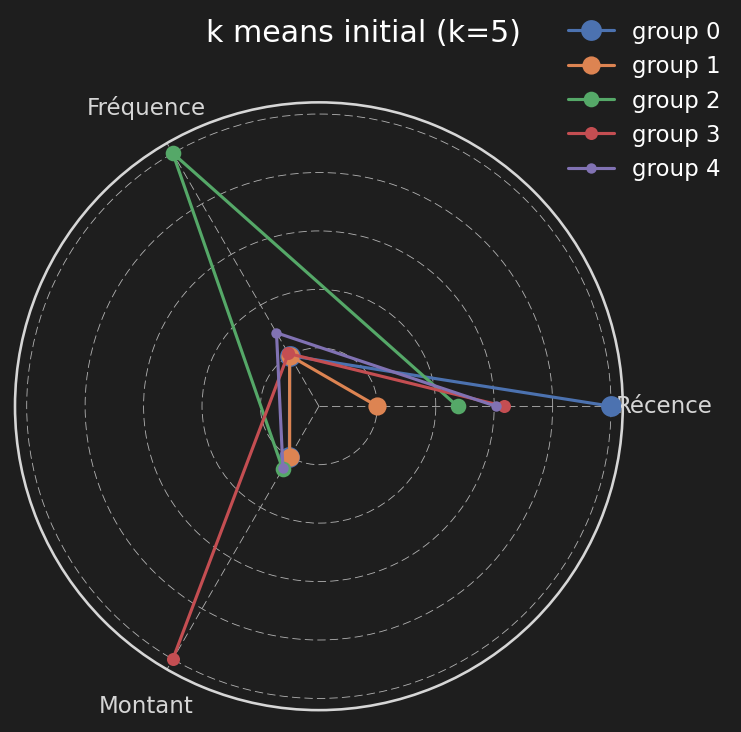

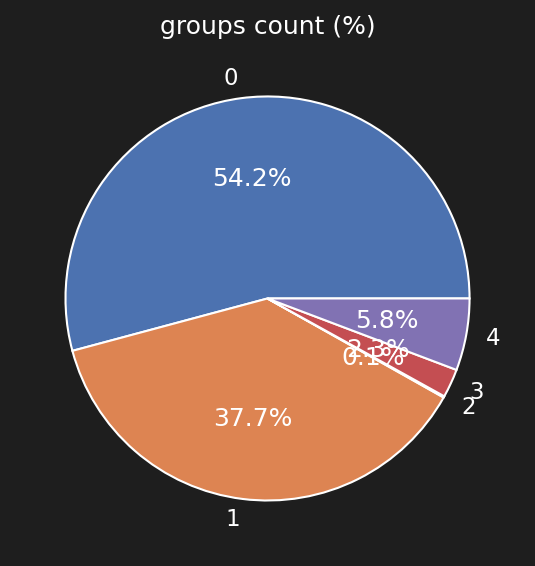

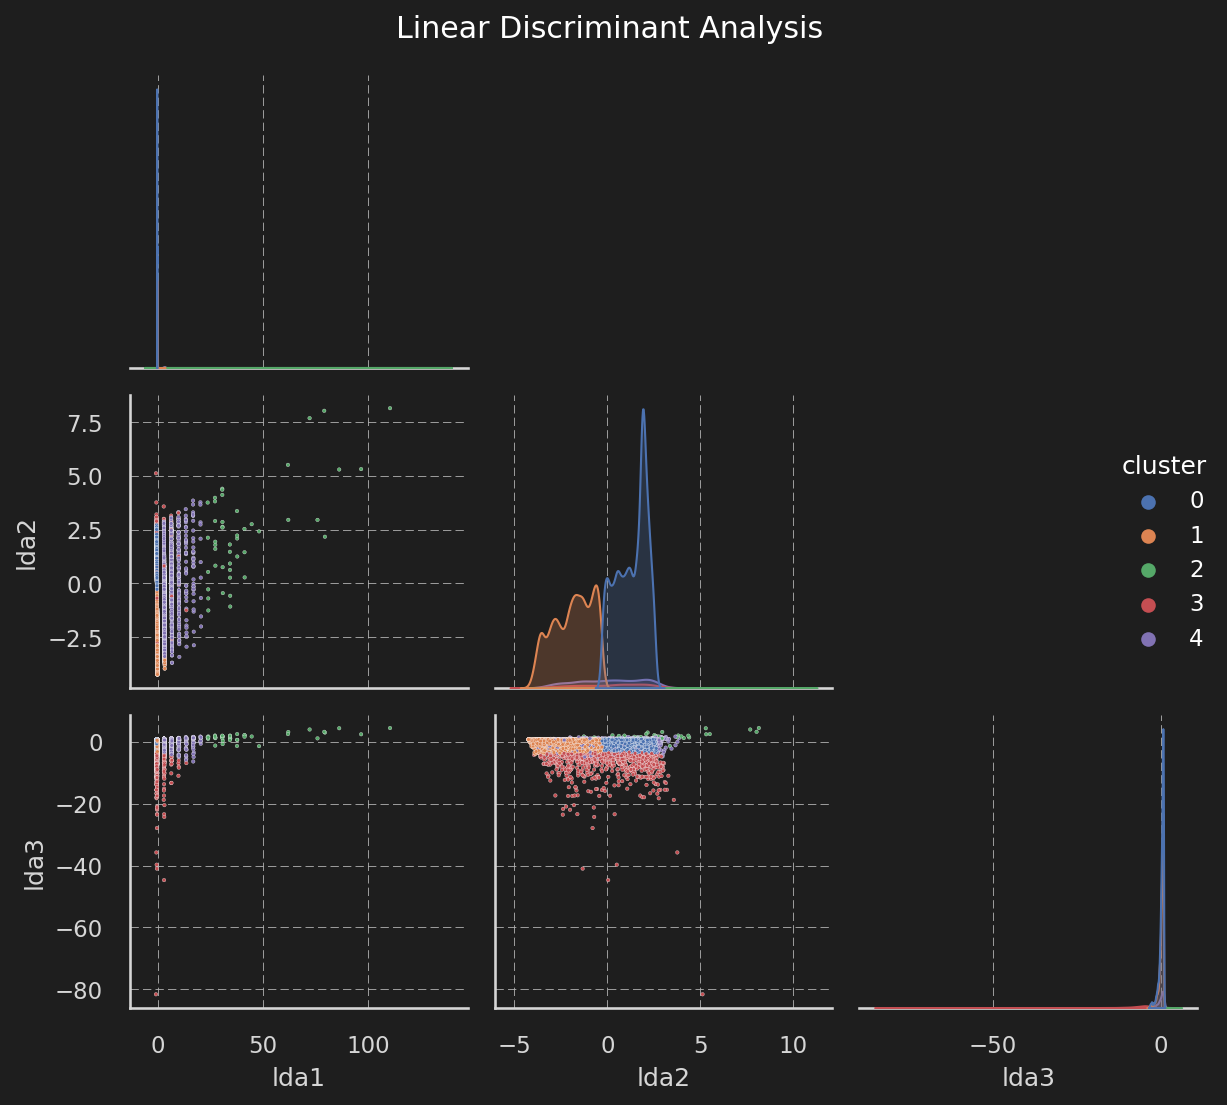

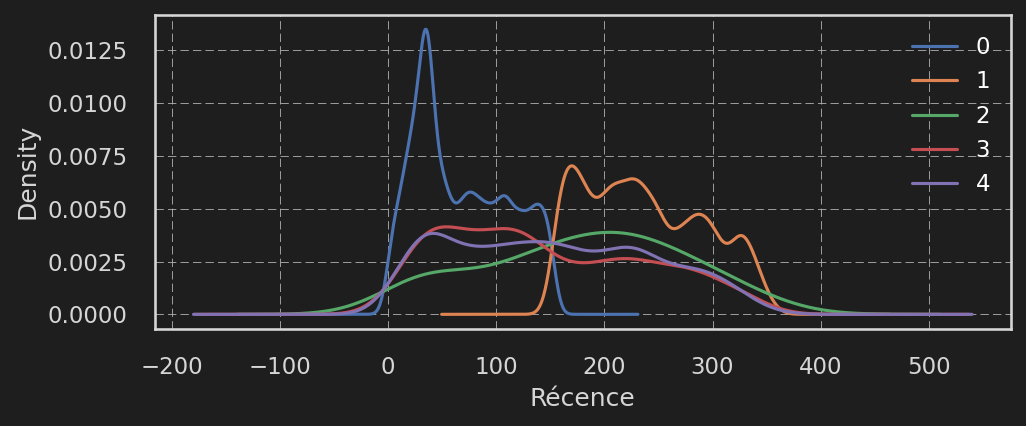

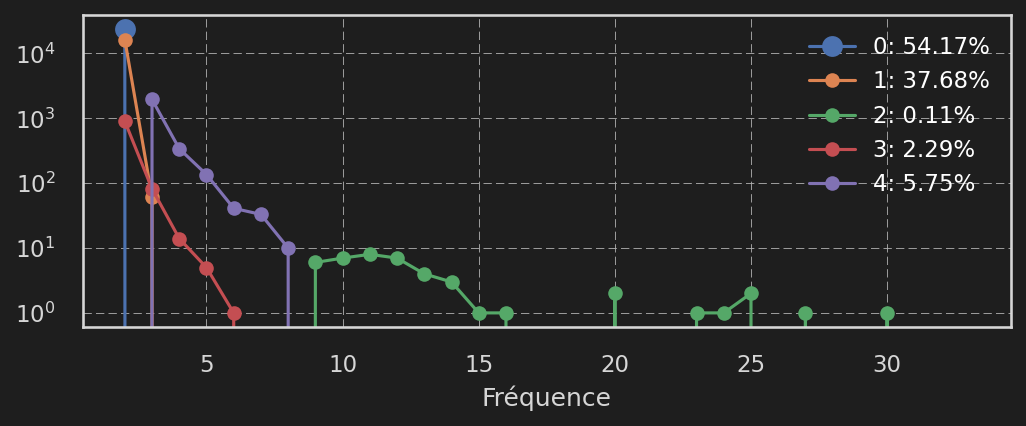

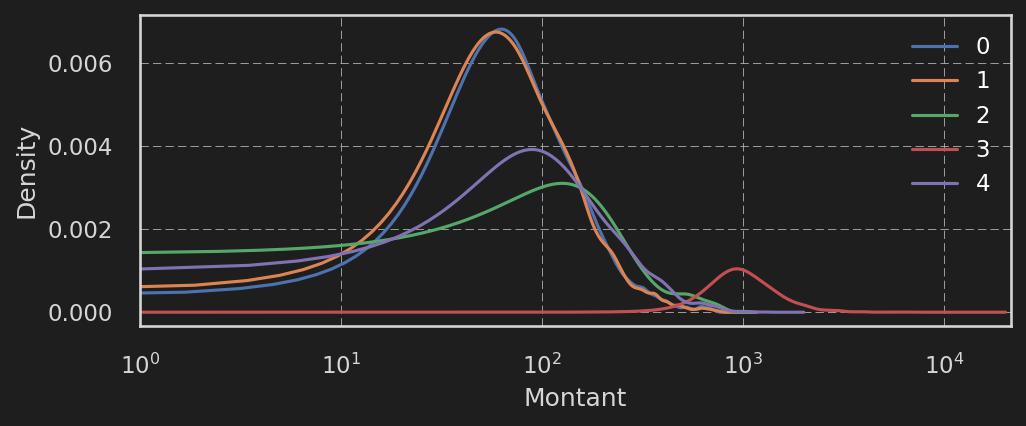

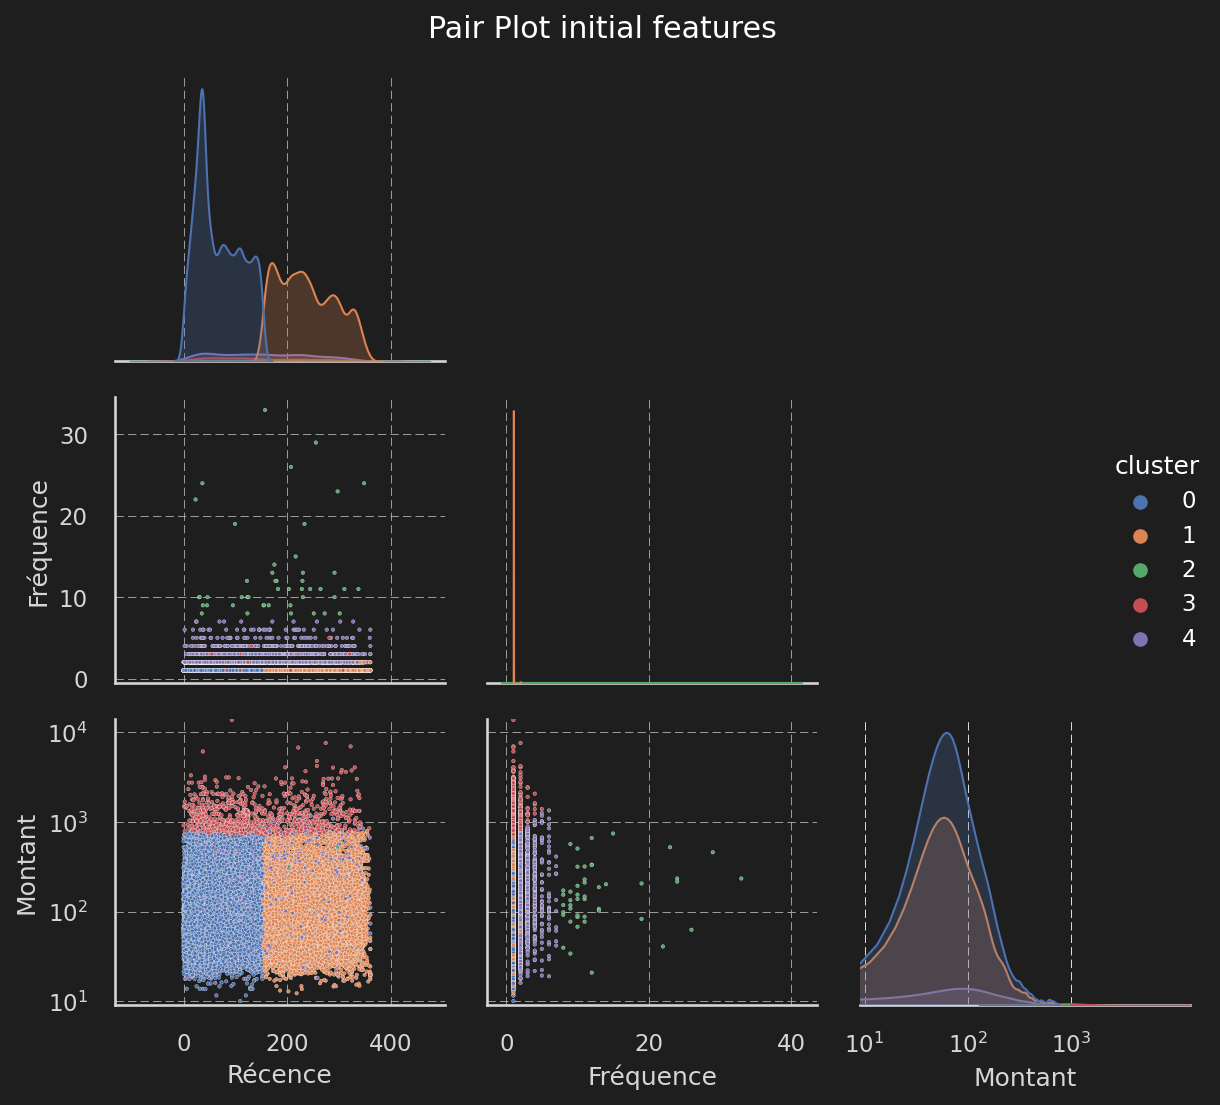

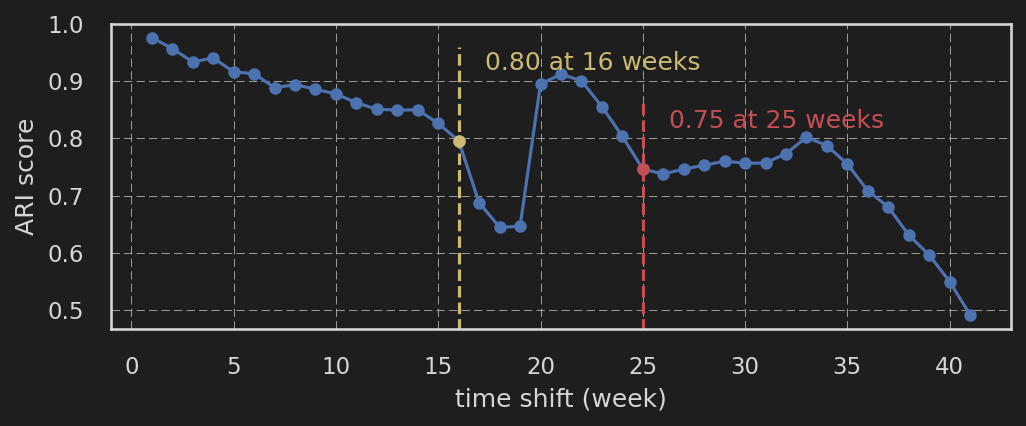

In [50]:
k = 5
compute_ARI_full(df_merged, t0, timespan, timeshift, k)

## 3.2. <a id='toc3_2_'></a>[k = 4](#toc0_)

,Récence,Fréquence,Montant,count,count (%)
0,236.730000,1.090000,137.300000,17609,40.280000
1,145.000000,1.210000,1181.960000,1223,2.800000
2,164.730000,8.410000,227.110000,125,0.290000
3,68.270000,1.060000,137.390000,24756,56.630000




|----------------------------------------|
                 4 labels                 

                     Multivariate linear model
                                                                    
--------------------------------------------------------------------
       Intercept         Value  Num DF   Den DF     F Value   Pr > F
--------------------------------------------------------------------
          Wilks' lambda  0.0791 3.0000 43707.0000 169722.7141 0.0000
         Pillai's trace  0.9209 3.0000 43707.0000 169722.7141 0.0000
 Hotelling-Lawley trace 11.6496 3.0000 43707.0000 169722.7141 0.0000
    Roy's greatest root 11.6496 3.0000 43707.0000 169722.7141 0.0000
--------------------------------------------------------------------
                                                                    
--------------------------------------------------------------------
         cluster         Value  Num DF    Den DF    F Value   Pr > F
------------------------------------

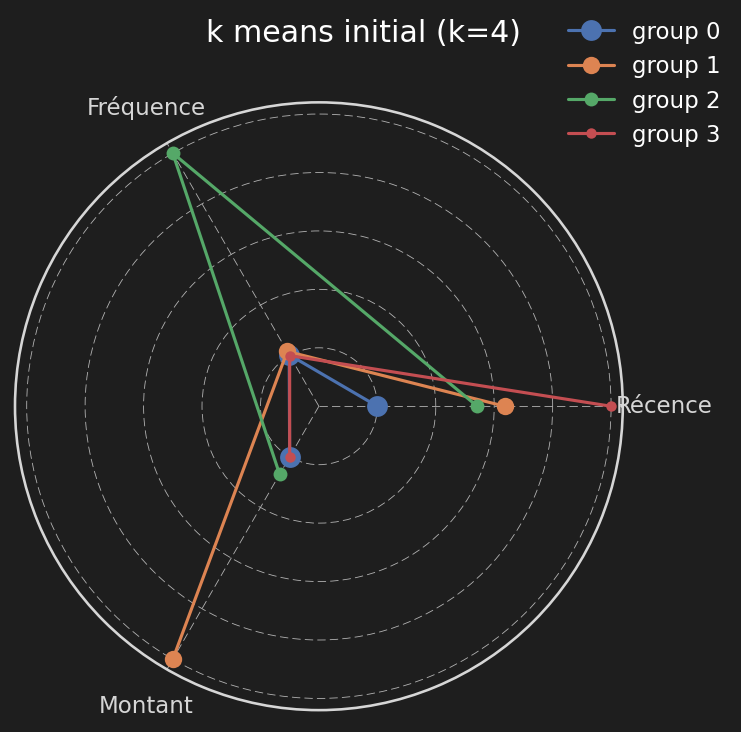

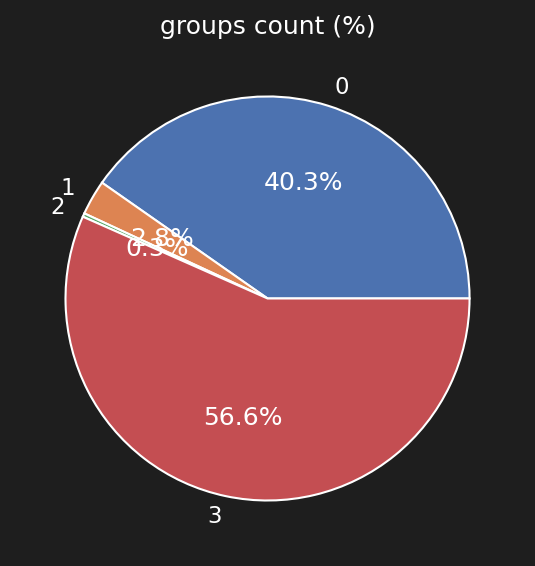

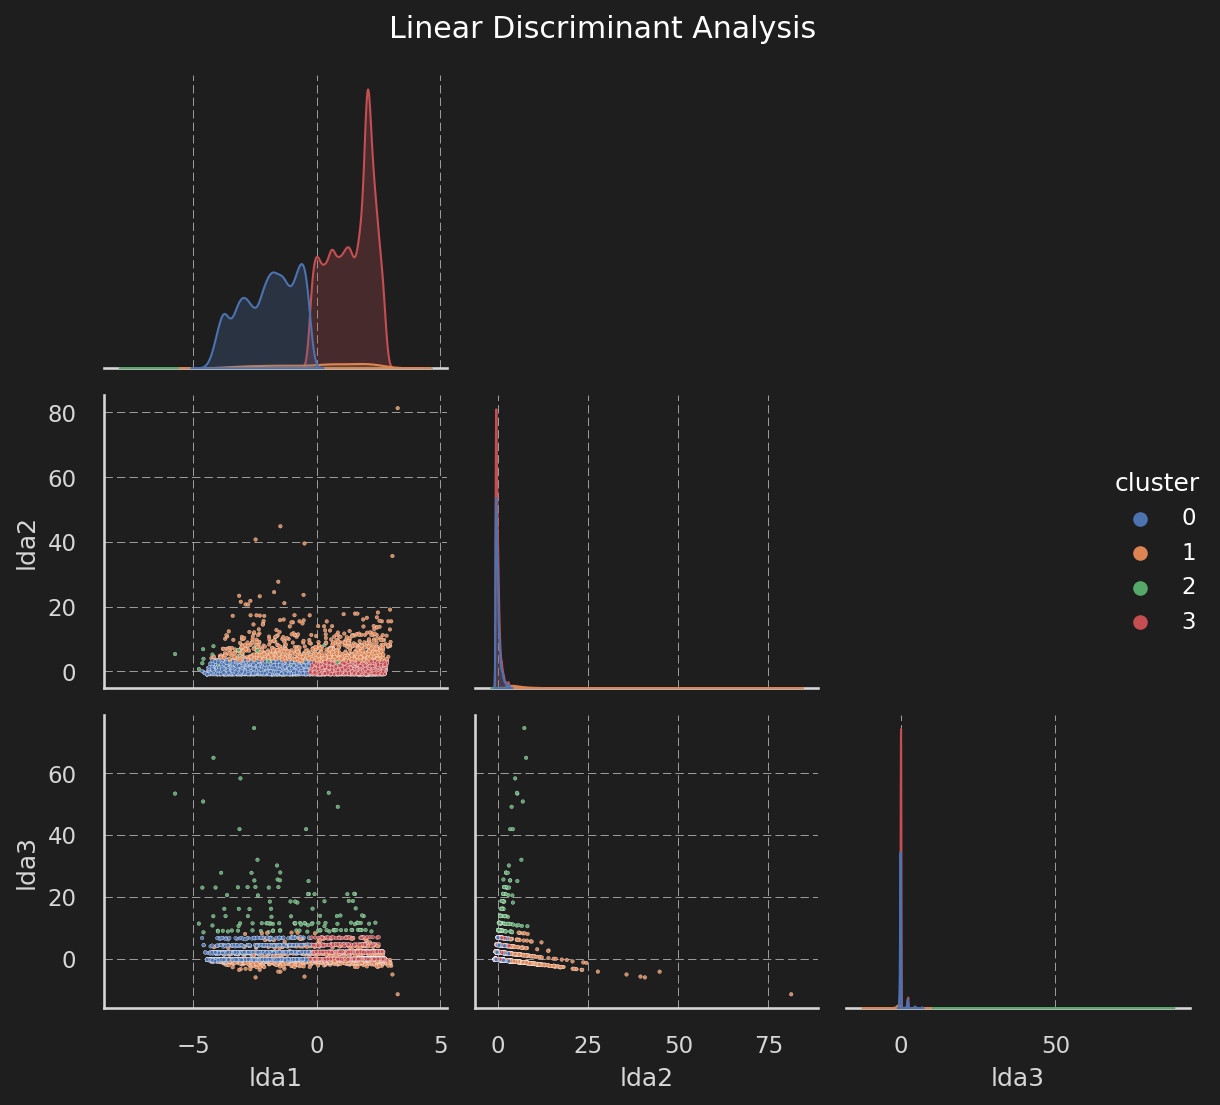

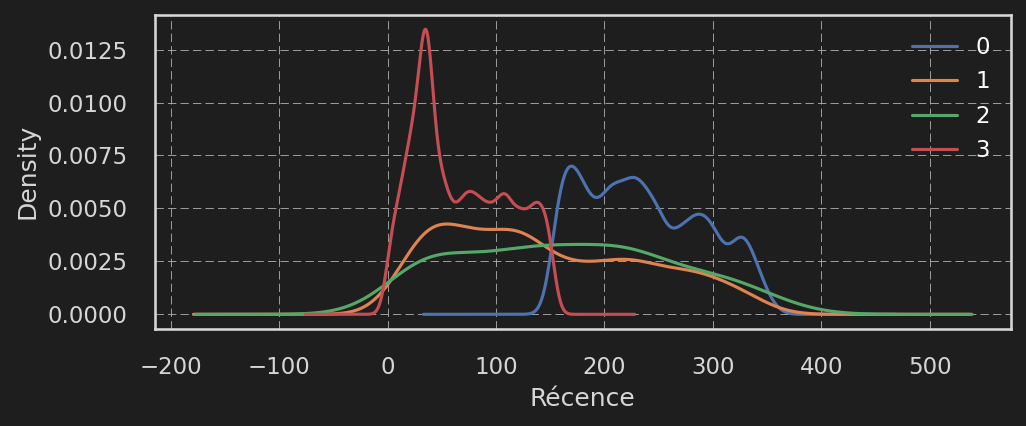

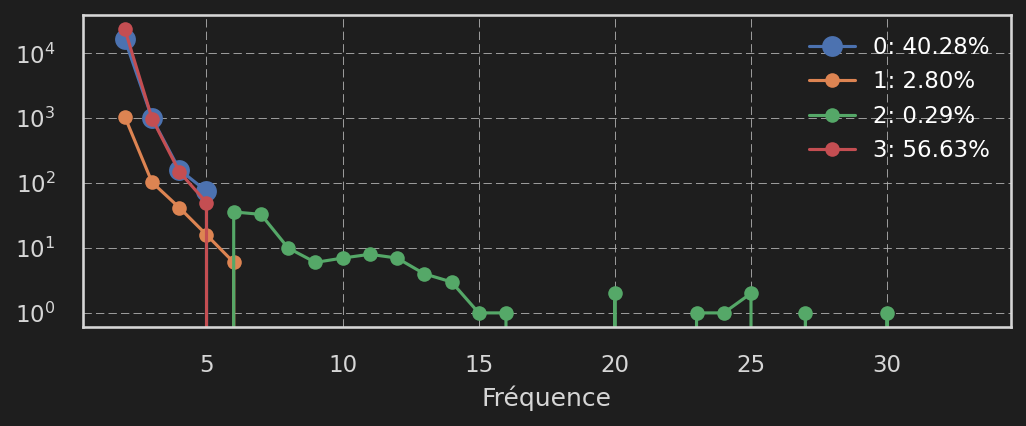

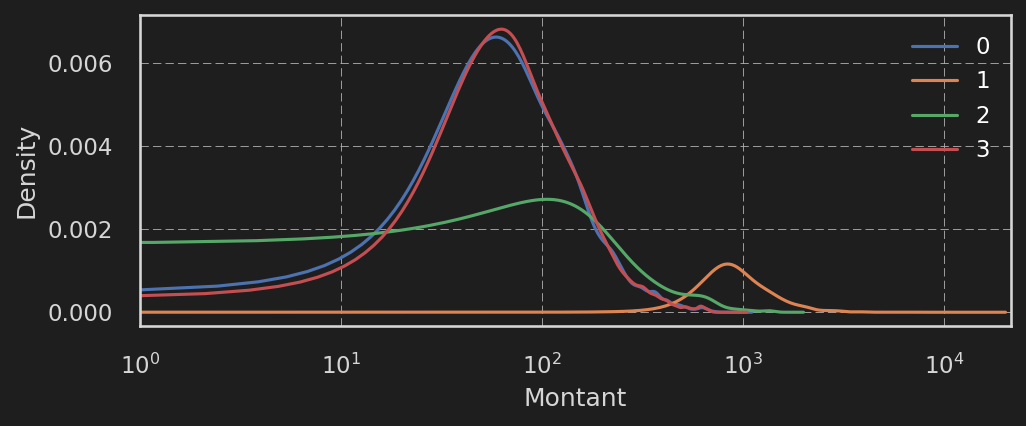

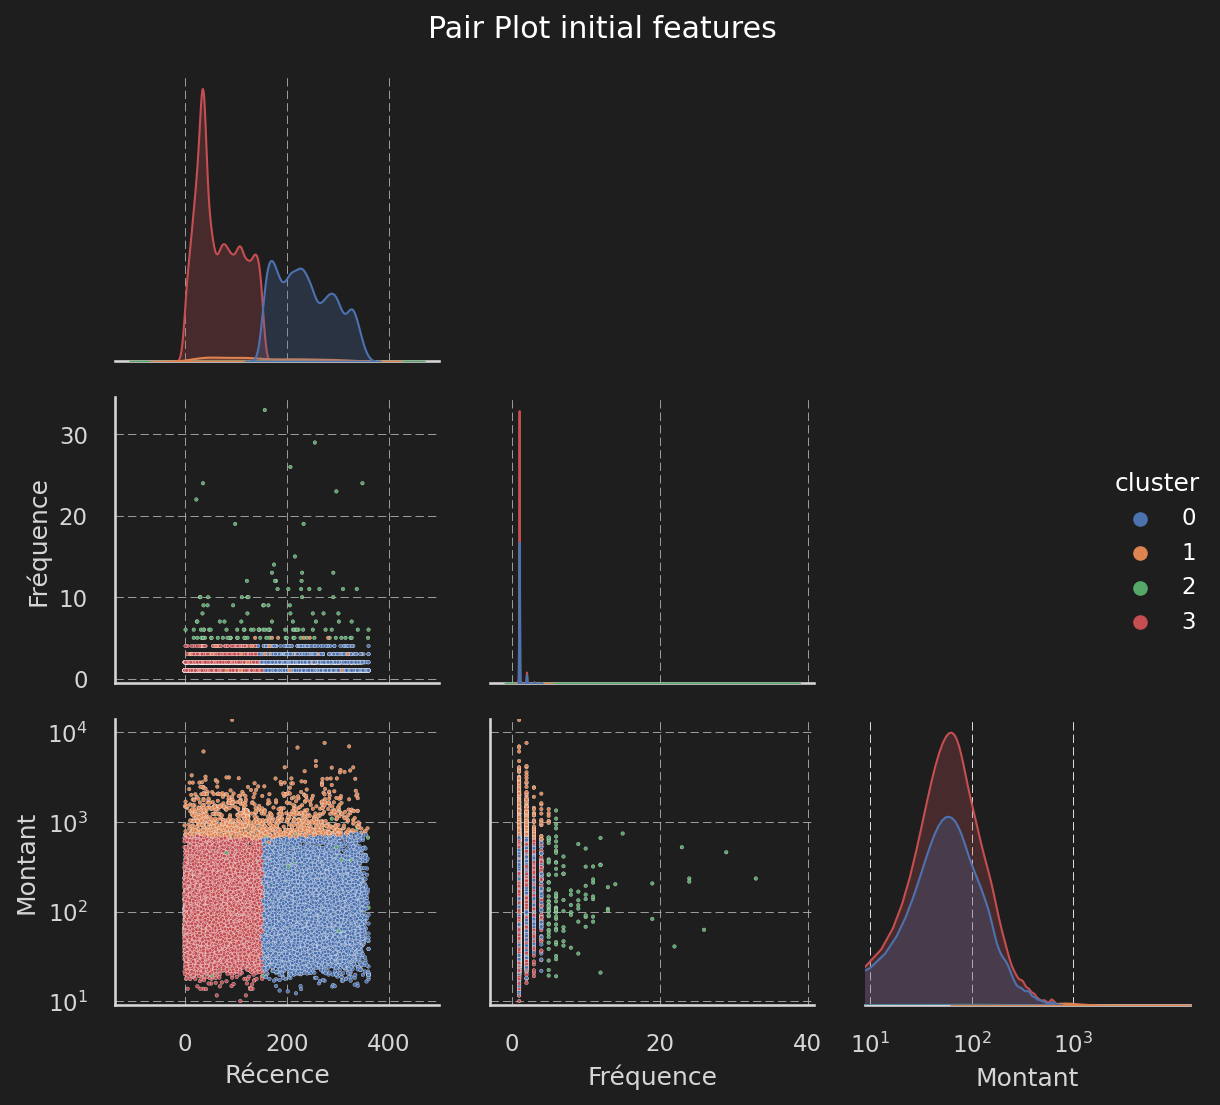

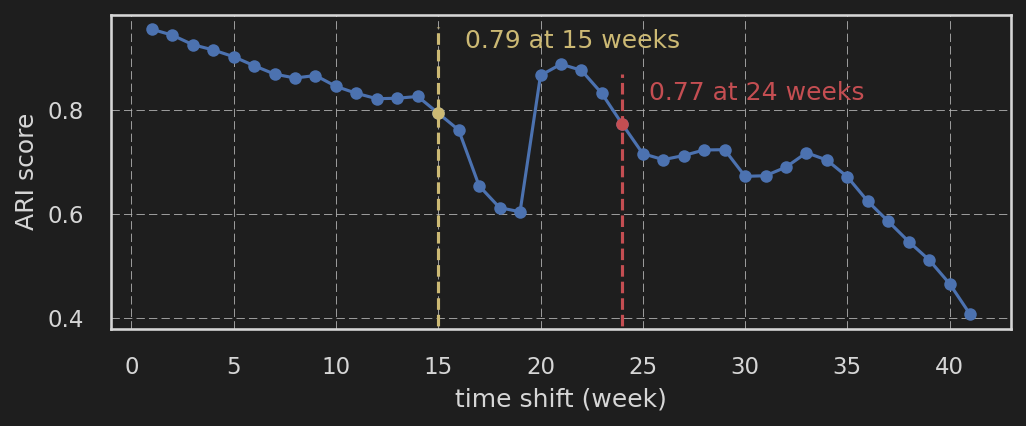

In [51]:
k = 4
compute_ARI_full(df_merged, t0, timespan, timeshift, k)

## 3.3. <a id='toc3_3_'></a>[Remarques](#toc0_)
* Prendre 4 clusters au lieu de 5 fusionne un petit cluster (correspondant aux fréquences les plus élevés) avec un plus gros proche (fréquences élevées élevés).
* le score ARI descend en dessous de 0.8 pour 16 / 25 semaines pour 5 clusters, et 15 / 24 semaines pour 4 clusters.
* le choix du nombre de clusters est à discuter avec Olist en fonction de leurs besoins